Esta versión de random forest es para el archivo de datos final a 26/02/2026, con la implementación de lag features.

In [1]:
# 0. Importar librerias
import pandas as pd
#from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [2]:
# 1. Cargar los datos ya procesados
df = pd.read_excel('datos.xlsx', header=0)
# Media de temperatura y humedad de las últimas 72 horas
# Esto le dice al modelo si el terreno viene "calentándose" días atrás
df['temp_media_3d'] = df['temperature_2m (°C)'].rolling(window=72).mean()
df['hum_media_3d'] = df['relative_humidity_2m (%)'].rolling(window=72).mean()

# Variación de presión en las últimas 6 horas (Detección de frentes)
df['delta_presion_6h'] = df['surface_pressure (hPa)'].diff(6)

df=df.dropna(axis=0)

In [3]:
print(df)

                     time  temperature_2m (°C)  relative_humidity_2m (%)  \
71    2017-01-06 23:00:00                  8.3                        95   
72    2017-01-07 00:00:00                  7.9                        96   
73    2017-01-07 01:00:00                  7.1                        97   
74    2017-01-07 02:00:00                  7.0                        97   
75    2017-01-07 03:00:00                  6.9                        97   
...                   ...                  ...                       ...   
70051 2024-12-31 19:00:00                  9.4                        77   
70052 2024-12-31 20:00:00                  8.0                        83   
70053 2024-12-31 21:00:00                  7.4                        87   
70054 2024-12-31 22:00:00                  6.6                        88   
70055 2024-12-31 23:00:00                  5.9                        89   

       surface_pressure (hPa)  wind_speed_10m (km/h)  wind_direction_10m (°)  \
71     

In [6]:
#Creamos los vectores X e Y
from sklearn.model_selection import train_test_split

X = df.drop(columns=['time', 'incendio'])
y = df['incendio']
# 3. División en entrenamiento y prueba (80% tren, 20% test)
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=42)
original_column_names = list(X_train.columns)


In [7]:
# Definir la rejilla de parámetros a probar
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [8, 12, 20],
    'max_features' : ['sqrt'],
    'min_samples_split': [2, 4, 6, 10],
    'class_weight': ['balanced'] # 'balanced' ayuda si hay pocos incendios
}

# Configurar la búsqueda (cv=3 significa que divide los datos en 3 para validar)
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), 
                           param_grid=param_grid, 
                          cv=3, n_jobs=-1, scoring='f1')
from sklearn.model_selection import RandomizedSearchCV

#random_search = RandomizedSearchCV(
#    estimator=RandomForestClassifier(random_state=42),
#    param_distributions=param_grid,
#    n_iter=5, # Solo prueba 20 combinaciones aleatorias
#    cv=3, 
#    n_jobs=-1, 
#    scoring='f1',
#    random_state=42,
#    verbose=2
#)
# Entrenar buscando la mejor combinación
grid_search.fit(X_train, Y_train)
#random_search.fit(X_train, Y_train)

# El mejor modelo encontrado
best_rf = grid_search.best_params_
#best_rf=random_search.best_params_
print(f"Mejores parámetros encontrados: {best_rf}")

# Usar el mejor modelo para predecir
y_pred_opt = grid_search.best_estimator_.predict(X_test)
#y_pred_opt = random_search.best_estimator_.predict(X_test)

Mejores parámetros encontrados: {'class_weight': 'balanced', 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 6, 'n_estimators': 100}


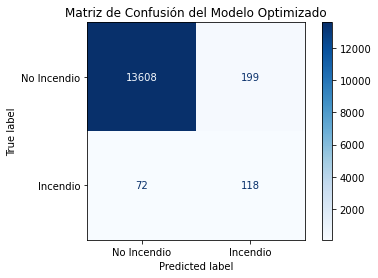

In [8]:
# Crear la matriz
cm = confusion_matrix(Y_test, y_pred_opt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Incendio', 'Incendio'])

# Dibujar
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión del Modelo Optimizado")
plt.show()

In [9]:
# 1. Buscamos los índices (los números de la izquierda) que corresponden a esas fechas
mask_incendio = (df.iloc[:, 0] >= "2022-07-25 15:00") & (df.iloc[:, 0] <= "2022-07-28 23:59")
indices_incendio = df[mask_incendio].index

print(indices_incendio)

Index([48687, 48688, 48689, 48690, 48691, 48692, 48693, 48694, 48695, 48696,
       48697, 48698, 48699, 48700, 48701, 48702, 48703, 48704, 48705, 48706,
       48707, 48708, 48709, 48710, 48711, 48712, 48713, 48714, 48715, 48716,
       48717, 48718, 48719, 48720, 48721, 48722, 48723, 48724, 48725, 48726,
       48727, 48728, 48729, 48730, 48731, 48732, 48733, 48734, 48735, 48736,
       48737, 48738, 48739, 48740, 48741, 48742, 48743, 48744, 48745, 48746,
       48747, 48748, 48749, 48750, 48751, 48752, 48753, 48754, 48755, 48756,
       48757, 48758, 48759, 48760, 48761, 48762, 48763, 48764, 48765, 48766,
       48767],
      dtype='int64')


In [10]:
# 2. Creamos un DataFrame de resultados uniendo y_test e y_pred_opt
# Importante: X_test conserva el índice original (ej: 71, 72...)
df_resultados = pd.DataFrame({
    'real': Y_test,
    'prediccion': y_pred_opt
}, index=X_test.index)

df_resultados

,real,prediccion
17033,0,0
8368,0,0
55266,0,0
53355,0,0
26001,0,0
...,...,...
39939,1,1
11252,0,0
32002,0,0
68343,0,0


In [11]:
# 3. Filtramos df_resultados usando solo los índices que encontramos en el paso 1
# Esto selecciona solo las filas del incendio que cayeron en tu set de TEST
df_incendio_test = df_resultados.loc[df_resultados.index.isin(indices_incendio)]

df_incendio_test

,real,prediccion
48706,1,1
48698,1,1
48687,1,0
48726,1,1
48729,1,1
48761,1,1
48704,1,1
48753,1,0
48713,1,1
48701,1,1


In [12]:

# 4. Recuperamos las fechas para el eje X
df_incendio_test['fecha'] = df.loc[df_incendio_test.index, df.columns[0]]
df_incendio_test = df_incendio_test.sort_values('fecha')
 
df_incendio_test

C:\Users\silvi\AppData\Local\Temp/ipykernel_18792/1926985101.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_incendio_test['fecha'] = df.loc[df_incendio_test.index, df.columns[0]]


,real,prediccion,fecha
48687,1,0,2022-07-25 15:00:00
48691,1,1,2022-07-25 19:00:00
48693,1,1,2022-07-25 21:00:00
48698,1,1,2022-07-26 02:00:00
48701,1,1,2022-07-26 05:00:00
48704,1,1,2022-07-26 08:00:00
48706,1,1,2022-07-26 10:00:00
48707,1,1,2022-07-26 11:00:00
48713,1,1,2022-07-26 17:00:00
48714,1,1,2022-07-26 18:00:00


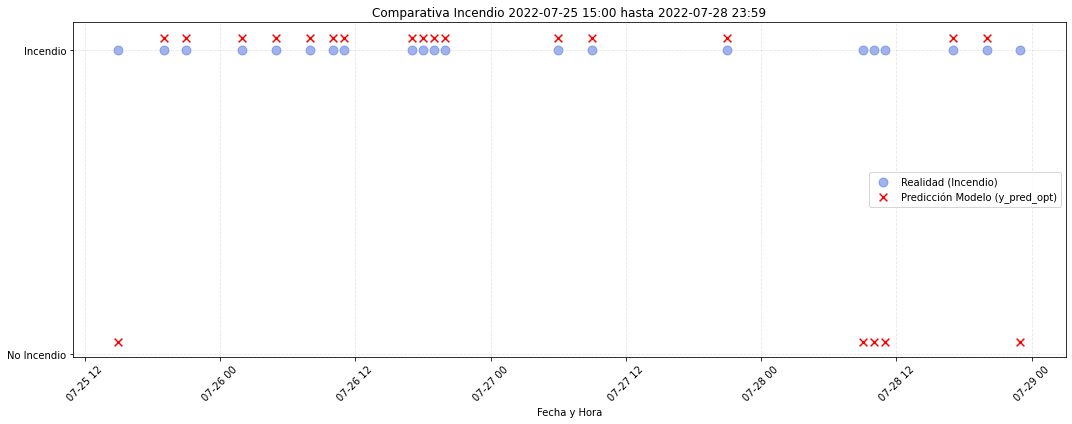

Se han graficado 21 horas de datos que estaban en el set de prueba.


In [13]:

# --- Visualización ---
plt.figure(figsize=(15, 6))

# Dibujamos la realidad
plt.scatter(df_incendio_test['fecha'], df_incendio_test['real'], 
            color='royalblue', label='Realidad (Incendio)', s=80, alpha=0.5)

# Dibujamos la predicción (con el pequeño desplazamiento para que se vea la diferencia)
plt.scatter(df_incendio_test['fecha'], df_incendio_test['prediccion'] + 0.04, 
            color='red', marker='x', label='Predicción Modelo (y_pred_opt)', s=60)

plt.yticks([0, 1], ['No Incendio', 'Incendio'])
plt.title('Comparativa Incendio 2022-07-25 15:00 hasta 2022-07-28 23:59')
plt.xlabel('Fecha y Hora')
plt.grid(True, axis='both', linestyle='--', alpha=0.3)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Se han graficado {len(df_incendio_test)} horas de datos que estaban en el set de prueba.")

In [14]:
# Finalmente, contamos cuantas horas de incendio predice bien

total_incendios_predichos = df_incendio_test['prediccion'].sum()

print(f'Se han detectado {total_incendios_predichos} horas del incendio de {len(df_incendio_test)}. ' )

Se han detectado 16 horas del incendio de 21. 


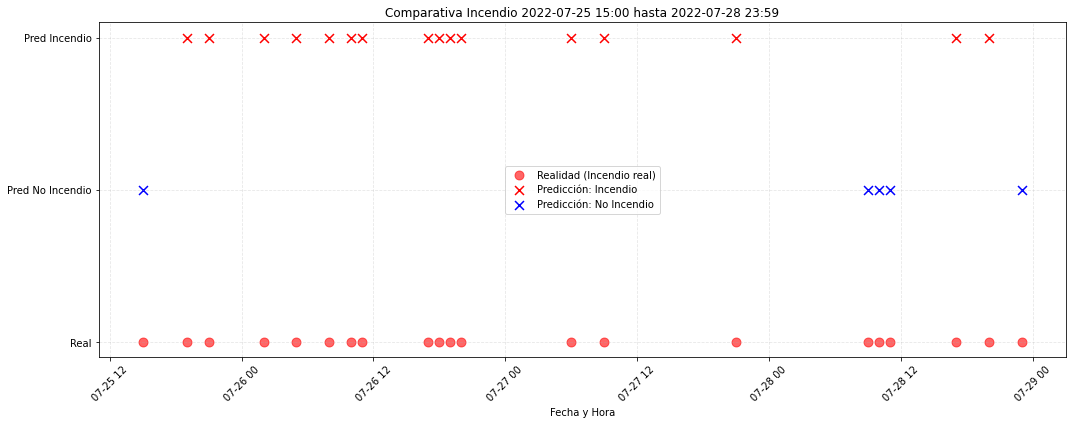

Se han detectado 16 horas del incendio de 21 horas. 


In [15]:
# --- Visualización ---
plt.figure(figsize=(15, 6))

# --- REALIDAD: siempre abajo en rojo ---
plt.scatter(
    df_incendio_test['fecha'], 
    [0]*len(df_incendio_test),   # todos abajo
    color='red', 
    label='Realidad (Incendio real)', 
    s=80, 
    alpha=0.6
)

# --- PREDICCIONES ---
# Predicción = 1 (Incendio) -> cruces rojas arriba
pred_si = df_incendio_test[df_incendio_test['prediccion'] == 1]
plt.scatter(
    pred_si['fecha'], 
    [1]*len(pred_si), 
    color='red', 
    marker='x', 
    label='Predicción: Incendio', 
    s=80
)

# Predicción = 0 (No incendio) -> cruces azules a otra altura
pred_no = df_incendio_test[df_incendio_test['prediccion'] == 0]
plt.scatter(
    pred_no['fecha'], 
    [0.5]*len(pred_no),  # altura intermedia
    color='blue', 
    marker='x', 
    label='Predicción: No Incendio', 
    s=80
)

# Ejes y estilo
plt.yticks([0, 0.5, 1], ['Real', 'Pred No Incendio', 'Pred Incendio'])
plt.title('Comparativa Incendio 2022-07-25 15:00 hasta 2022-07-28 23:59')
plt.xlabel('Fecha y Hora')
plt.grid(True, axis='both', linestyle='--', alpha=0.3)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Finalmente, contamos cuantas horas de incendio predice bien

total_incendios_predichos = df_incendio_test['prediccion'].sum()

print(f'Se han detectado {total_incendios_predichos} horas del incendio de {len(df_incendio_test)} horas. ' )


--- Importancia de las Variables ---
                    Variable  Importancia
15              hum_media_3d     0.309401
14             temp_media_3d     0.211217
9                  temp_t-24     0.072588
0        temperature_2m (°C)     0.051681
8                   temp_t-1     0.049911
11                  hum_t-24     0.042519
2     surface_pressure (hPa)     0.040188
13               presion_t-2     0.036731
12               presion_t-1     0.030717
6    wind_direction_100m (°)     0.025484
4     wind_direction_10m (°)     0.022379
5     wind_speed_100m (km/h)     0.021428
7      wind_gusts_10m (km/h)     0.019856
1   relative_humidity_2m (%)     0.019672
3      wind_speed_10m (km/h)     0.017606
10                   hum_t-1     0.016683
16          delta_presion_6h     0.011940


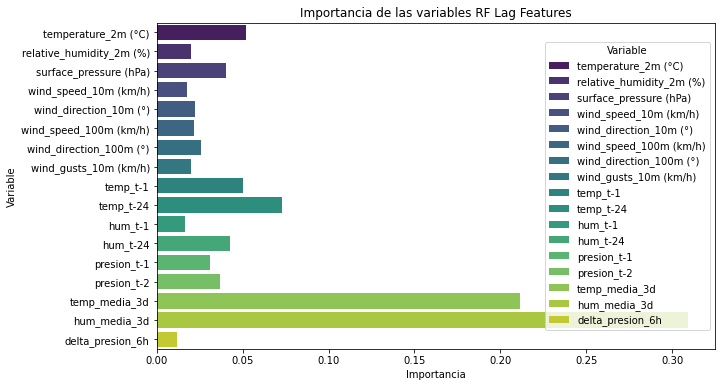

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# 6. Importancia de las variables (¿Qué causa más incendios?)
importancia = pd.DataFrame({'Variable': X_train.columns, 'Importancia':grid_search.best_estimator_.feature_importances_})
print("\n--- Importancia de las Variables ---")
print(importancia.sort_values(by='Importancia', ascending=False))

plt.figure(figsize=(10,6))
sns.barplot(x='Importancia', y='Variable', data=importancia, hue='Variable',
    dodge=False,
    palette='viridis')
plt.title("Importancia de las variables RF Lag Features")
plt.show()

In [18]:
import joblib

joblib.dump(grid_search.best_estimator_, 'modelo_rf_Lag.pkl')

['modelo_rf_Lag.pkl']

In [20]:
joblib.dump(X_test, 'X_test_Lag.pkl')
joblib.dump(Y_test, 'Y_test_Lag.pkl')
joblib.dump(original_column_names, 'columns_Lag.pkl')

['columns_Lag.pkl']